<a href="https://colab.research.google.com/github/vaibhavkatex/The-Internship-2026/blob/main/Session_28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 28 (AIML) - Assignment: NLP Preprocessing

In [3]:
# Importing required libraries
import pandas as pd
import numpy as np
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Q1. Loading the Dataset
Please ensure `train.txt` is placed in the same folder.

In [15]:
    # Load the dataset using pandas
    df = pd.read_csv('train.txt', sep=';', names=['text', 'emotions'])

    print("Shape of the dataset:", df.shape)
    print("\nFirst 10 rows:")
    display(df.head(10))

    print("\nMissing values:")
    print(df.isnull().sum())

Shape of the dataset: (16000, 2)

First 10 rows:


,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love



Missing values:
text        0
emotions    0
dtype: int64


## Q2. Exploring Target Labels

In [5]:
if 'df' in locals():
    # 1. Find all unique emotion labels
    unique_emotions = df['emotions'].unique()
    print("Unique Emotion Labels:", unique_emotions)

    # 2. Use LabelEncoder to convert to numeric
    le = LabelEncoder()
    df['encoded_emotions'] = le.fit_transform(df['emotions'])

    # 3. Create a dictionary mapping
    emotion_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("\nEmotion Label Mapping:")
    print(emotion_mapping)

    # 4. Display the DataFrame
    display(df.head())

Unique Emotion Labels: ['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion Label Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


,text,emotions,encoded_emotions
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


## Q3. Lowercasing

In [6]:
if 'df' in locals():
    print("Before Lowercasing (5 samples):")
    display(df['text'].head())

    # Convert text column to lowercase
    df['text'] = df['text'].str.lower()

    print("\nAfter Lowercasing (5 samples):")
    display(df['text'].head())

Before Lowercasing (5 samples):


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy



After Lowercasing (5 samples):


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


**Note on Lowercasing:**
Lowercasing is critical in NLP to maintain consistency. Without it, the words 'Happy', 'happy', and 'HAPPY' would be treated as completely different vocabulary tokens by the machine learning model. Converting everything to lowercase reduces the dimensionality of the feature space and ensures semantic grouping.

## Q4. Removing Punctuation

In [7]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

if 'df' in locals():
    print("Before Punctuation Removal:")
    display(df['text'].head())

    df['text'] = df['text'].apply(remove_punctuation)

    print("\nAfter Punctuation Removal:")
    display(df['text'].head())

Before Punctuation Removal:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy



After Punctuation Removal:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


## Q5. Removing Numbers

In [8]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

if 'df' in locals():
    print("Before Removing Numbers:")
    # Finding some rows that might have numbers for demonstration, fallback to head()
    sample_with_nums = df[df['text'].str.contains(r'\d', na=False, regex=True)].head()
    if sample_with_nums.empty:
        sample_with_nums = df.head()
    display(sample_with_nums['text'])

    df['text'] = df['text'].apply(remove_numbers)

    print("\nAfter Removing Numbers:")
    display(df.loc[sample_with_nums.index, 'text'])

Before Removing Numbers:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy



After Removing Numbers:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


## Q6. Removing Emojis & Special Characters

In [9]:
def remove_non_ascii(text):
    # Keeps only standard ASCII characters
    return text.encode('ascii', 'ignore').decode('ascii')

if 'df' in locals():
    print("Before ASCII filtering:")
    display(df['text'].head())

    df['text'] = df['text'].apply(remove_non_ascii)

    print("\nAfter ASCII filtering:")
    display(df['text'].head())

Before ASCII filtering:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy



After ASCII filtering:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy


## Q7. Removing Stopwords

In [10]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

if 'df' in locals():
    print("Before Removing Stopwords:")
    display(df['text'].head())

    df['text'] = df['text'].apply(remove_stopwords)

    print("\nAfter Removing Stopwords:")
    display(df['text'].head())

Before Removing Stopwords:


,text
0,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy



After Removing Stopwords:


,text
0,didnt feel humiliated
1,go feeling hopeless damned hopeful around some...
2,im grabbing minute post feel greedy wrong
3,ever feeling nostalgic fireplace know still pr...
4,feeling grouchy


## Q8. Complete Text Cleaning Pipeline

In [11]:
def clean_text_pipeline(text):
    text = str(text).lower()                                                  # Lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))          # Remove Punctuation
    text = re.sub(r'\d+', '', text)                                            # Remove Numbers
    text = text.encode('ascii', 'ignore').decode('ascii')                     # Keep ASCII only

    # Remove Stopwords
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    text = " ".join(filtered_words)
    return text

if 'df' in locals():
    # Reloading fresh dataframe to demonstrate full pipeline from scratch
    df_original = pd.read_csv('train.txt', sep=';', names=['text', 'emotions'])

    # Apply the full pipeline
    df_original['cleaned_text'] = df_original['text'].apply(clean_text_pipeline)

    # Display original text alongside cleaned text
    display(df_original[['text', 'cleaned_text']].head(10))

,text,cleaned_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas years feel petronas performed well ma...
9,i feel romantic too,feel romantic


## Q9. Text Length Analysis

Average Text Length: 9.35 words
Minimum Text Length: 1 words
Maximum Text Length: 35 words


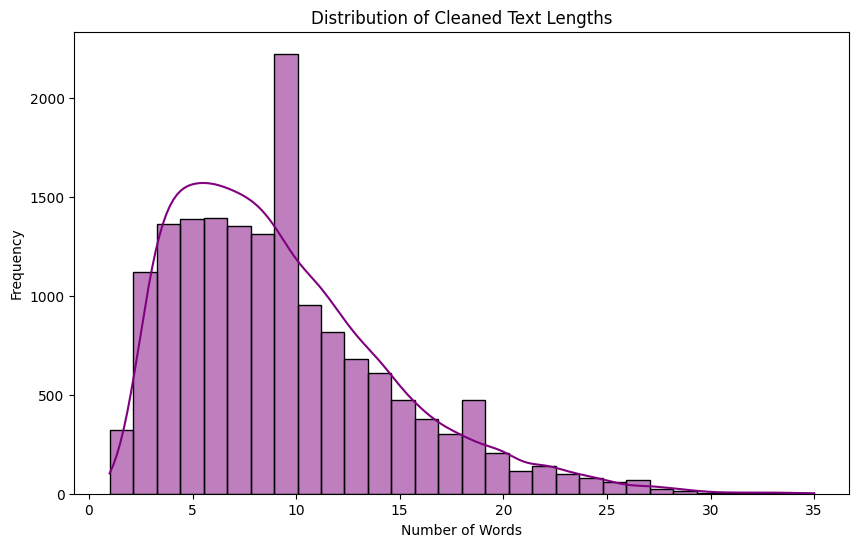

In [12]:
if 'df' in locals():
    # Calculate number of words in each cleaned text
    df_original['word_count'] = df_original['cleaned_text'].apply(lambda x: len(x.split()))

    # Calculate metrics
    avg_len = df_original['word_count'].mean()
    min_len = df_original['word_count'].min()
    max_len = df_original['word_count'].max()

    print(f"Average Text Length: {avg_len:.2f} words")
    print(f"Minimum Text Length: {min_len} words")
    print(f"Maximum Text Length: {max_len} words")

    # Plot histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df_original['word_count'], bins=30, kde=True, color='purple')
    plt.title("Distribution of Cleaned Text Lengths")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

**Observations:**
The histogram typically shows a right-skewed distribution, meaning the vast majority of the text sequences in the emotions dataset are relatively short (often concentrated around the average). There are very few long outlier sequences that form a tail on the right side.

## Q10. Mini Project – Full Preprocessing Pipeline

Successfully saved 'cleaned_emotions.csv'

Value Counts of each emotion:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


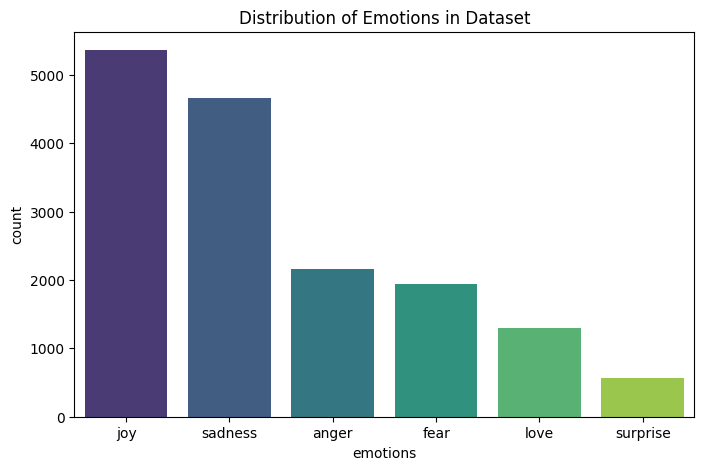

In [13]:
if 'df' in locals():
    # 1. Load data
    final_df = pd.read_csv('train.txt', sep=';', names=['text', 'emotions'])

    # 2. Encode emotion labels
    label_enc = LabelEncoder()
    final_df['encoded_emotions'] = label_enc.fit_transform(final_df['emotions'])

    # 3. Perform complete text cleaning
    final_df['cleaned_text'] = final_df['text'].apply(clean_text_pipeline)

    # 4. Save the cleaned dataset
    final_df.to_csv('cleaned_emotions.csv', index=False)
    print("Successfully saved 'cleaned_emotions.csv'")

    # 5. Show value counts of each emotion
    print("\nValue Counts of each emotion:")
    print(final_df['emotions'].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(x='emotions', data=final_df, order=final_df['emotions'].value_counts().index, palette='viridis')
    plt.title("Distribution of Emotions in Dataset")
    plt.show()